In [1]:
# conda activate anndata

import numpy as np
import pandas as pd
import anndata as ad

In [7]:
prefix = "janssens_2025_preprint_Chronocell_eLNPs_var>1.5"

In [24]:
cell_meta = pd.read_csv(f"data/{prefix}_traj_X_row_metadata.csv")

orig_corr = pd.read_csv("data/janssens_2025_preprint_author_counts_eLNP_RNA_vs_ADT_corrs.csv")
expr_ADT_imputed = pd.read_csv(f"data/{prefix}_RNA_history_imputed_protein.csv")
orig_corr = orig_corr.loc[orig_corr['Gene'].isin(expr_ADT_imputed.columns)]
expr_ADT = pd.read_csv("data/janssens_2025_preprint_author_ADT_counts_eLNP.csv", index_col=0)
expr_RNA = pd.read_csv("data/janssens_2025_preprint_author_RNA_counts_eLNP.csv", index_col=0)

In [26]:
order = expr_ADT_imputed.columns
orig_corr_ordered = (orig_corr
    .set_index("Gene")
    .reindex(order)          # filters + orders to match `order`
    .reset_index()
)
orig_corr_ordered

,index,Protein,Cor,Mean_RNA_expr
0,Bst2,CD317,0.077469,1.050668
1,Cd63,CD63,0.413217,4.793494
2,Cd9,CD9,0.119955,1.861176
3,Itgb1,CD29,0.012668,2.492147
4,Lamp1,CD107a,0.147878,3.021922
5,Lgals3,Mac2,0.008389,9.397775
6,Notch2,Notch,-0.001676,0.105263
7,Procr,CD201,0.102938,0.832056
8,Vcam1,CD106,0.053864,0.523278


## Align cells between my data and author data

In [27]:
expr_ADT_imputed.index = cell_meta['Cell_ID']

expr_ADT.index = expr_ADT.index.str.replace("-1", "", regex=False)
expr_ADT.index = expr_ADT.index.str.replace("_", "-", regex=False)

expr_RNA.index = expr_RNA.index.str.replace("-1", "", regex=False)
expr_RNA.index = expr_RNA.index.str.replace("_", "-", regex=False)

In [28]:
expr_RNA = expr_RNA.loc[expr_ADT_imputed.index]
expr_ADT = expr_ADT.loc[expr_ADT_imputed.index]

In [29]:
np.all(expr_ADT_imputed.index == expr_ADT.index)

True

In [30]:
np.all(expr_ADT_imputed.index == expr_RNA.index)

True

In [31]:
expr_ADT_imputed.columns

Index(['Bst2', 'Cd63', 'Cd9', 'Itgb1', 'Lamp1', 'Lgals3', 'Notch2', 'Procr',
       'Vcam1'],
      dtype='object')

In [35]:
expr_ADT_imputed.columns == orig_corr_ordered['index']

array([ True,  True,  True,  True,  True,  True,  True,  True,  True])

In [36]:
expr_ADT_imputed.columns

Index(['Bst2', 'Cd63', 'Cd9', 'Itgb1', 'Lamp1', 'Lgals3', 'Notch2', 'Procr',
       'Vcam1'],
      dtype='object')

In [37]:
orig_corr_ordered

,index,Protein,Cor,Mean_RNA_expr
0,Bst2,CD317,0.077469,1.050668
1,Cd63,CD63,0.413217,4.793494
2,Cd9,CD9,0.119955,1.861176
3,Itgb1,CD29,0.012668,2.492147
4,Lamp1,CD107a,0.147878,3.021922
5,Lgals3,Mac2,0.008389,9.397775
6,Notch2,Notch,-0.001676,0.105263
7,Procr,CD201,0.102938,0.832056
8,Vcam1,CD106,0.053864,0.523278


### Calculate correlation between ADT and imputed ADT

In [38]:
expr_ADT_subset = expr_ADT.loc[:, orig_corr_ordered['Protein']]

In [42]:
expr_ADT_subset

,CD317,CD63,CD9,CD29,CD107a,Mac2,Notch,CD201,CD106
Cell_ID,,,,,,,,,
AAAGGGCTCTGAGCAT-6,1,0,0,2,0,0,0,0,1
AAACCCAAGGGAGTTC-6,0,0,3,0,0,0,0,0,1
AAAGGATTCACCCTCA-6,0,0,0,0,0,0,0,0,0
AAAGGTATCTCTCGAC-6,0,0,3,0,0,0,0,0,0
AAACGAACAACAAAGT-6,0,1,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
TTTGGAGGTCTCACGG-2,0,0,3,0,0,0,0,0,0
TTTGGAGTCGACGTCG-2,0,0,4,0,0,0,0,1,0
TTTGGAGCACAAGTTC-2,0,0,0,2,0,0,0,0,0


In [44]:
expr_ADT_imputed.columns = orig_corr_ordered['Protein']

In [47]:
new_corr = expr_ADT_imputed.corrwith(expr_ADT_subset)
new_corr

Protein
CD317     0.038498
CD63      0.047051
CD9       0.026473
CD29      0.041961
CD107a    0.029030
Mac2      0.001180
Notch    -0.005782
CD201     0.017640
CD106     0.006112
dtype: float64

In [48]:
corrs_df = (
    orig_corr
    .merge(
        new_corr.rename("New_cor").to_frame(),
        left_on="Protein",
        right_index=True,
        how="inner"   # use "left" if you want to keep all rows of orig_corr
    )
)

In [49]:
corrs_df

,Protein,Gene,Cor,Mean_RNA_expr,New_cor
4,CD106,Vcam1,0.053864,0.523278,0.006112
5,CD107a,Lamp1,0.147878,3.021922,0.029030
33,CD201,Procr,0.102938,0.832056,0.017640
45,CD29,Itgb1,0.012668,2.492147,0.041961
55,CD317,Bst2,0.077469,1.050668,0.038498
106,Mac2,Lgals3,0.008389,9.397775,0.001180
109,Notch,Notch2,-0.001676,0.105263,-0.005782
139,CD63,Cd63,0.413217,4.793494,0.047051
148,CD9,Cd9,0.119955,1.861176,0.026473


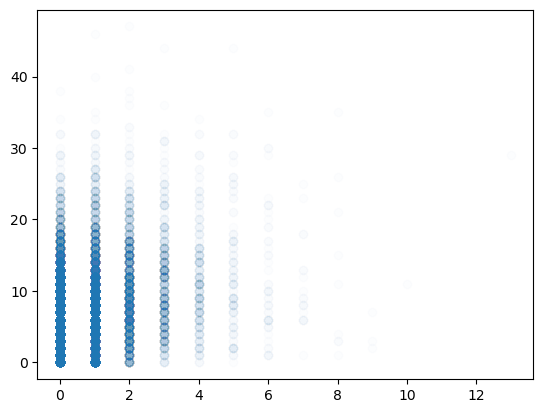

In [59]:
import matplotlib.pyplot as plt

plt.plot(expr_ADT['CD63'], expr_RNA['Cd63'], 'o', alpha=0.01)

In [54]:
np.corrcoef(expr_ADT['CD63'], expr_RNA['Cd63'])

array([[1.       , 0.4141189],
       [0.4141189, 1.       ]])